# 07 — Imbalanced Data & Feature Selection

Two practical problems that don't fit neatly into "just pick an algorithm":
**imbalanced classes** (where accuracy lies to you) and **feature selection**
(where fewer, better features can beat throwing everything at the model).

**Covered:**
1. Why imbalanced data breaks naive accuracy
2. Class weights
3. SMOTE (oversampling the minority class)
4. Feature importance & permutation importance
5. Recursive Feature Elimination (RFE)
6. SelectKBest (univariate statistical selection)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(6)

## 1. Why Imbalanced Data Breaks Naive Accuracy

Consider a dataset where 95% of samples are class 0 and only 5% are class 1
(e.g., fraud detection, rare disease screening). A classifier that **always
predicts class 0** gets 95% accuracy without learning anything.

In [2]:
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], flip_y=0.01, random_state=6,
)
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.3, random_state=6, stratify=y_imb)

print(f"Class distribution: {np.bincount(y_imb)} (class 0 : class 1 = {np.bincount(y_imb)[0]/len(y_imb):.1%} : {np.bincount(y_imb)[1]/len(y_imb):.1%})")

dummy_pred = np.zeros_like(y_test)  # always predicts class 0
print(f"\n'Always predict class 0' classifier:")
print(f"  accuracy  = {accuracy_score(y_test, dummy_pred):.3f}  <- looks great!")
print(f"  precision = {precision_score(y_test, dummy_pred, zero_division=0):.3f}")
print(f"  recall    = {recall_score(y_test, dummy_pred, zero_division=0):.3f}  <- catches ZERO of the class we actually care about")

Class distribution: [1888  112] (class 0 : class 1 = 94.4% : 5.6%)

'Always predict class 0' classifier:
  accuracy  = 0.943  <- looks great!
  precision = 0.000
  recall    = 0.000  <- catches ZERO of the class we actually care about


This is exactly why `06_model_selection_tuning` and `01_data_preprocessing`
emphasized precision/recall/F1 over accuracy — on imbalanced data, accuracy
alone can hide a completely useless model.

In [3]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=5000).fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Logistic Regression (no rebalancing):")
print(f"  accuracy={accuracy_score(y_test, baseline_pred):.3f}  precision={precision_score(y_test, baseline_pred):.3f}  "
      f"recall={recall_score(y_test, baseline_pred):.3f}  f1={f1_score(y_test, baseline_pred):.3f}")

Logistic Regression (no rebalancing):
  accuracy=0.965  precision=0.760  recall=0.559  f1=0.644


## 2. Class Weights

**Theory.** The simplest fix: tell the model to penalize mistakes on the
minority class more heavily during training, via `class_weight="balanced"`
(automatically weights classes inversely proportional to their frequency).
No data duplication required — just a reweighted loss function.

Logistic Regression (class_weight='balanced'):
  accuracy=0.882  precision=0.301  recall=0.824  f1=0.441


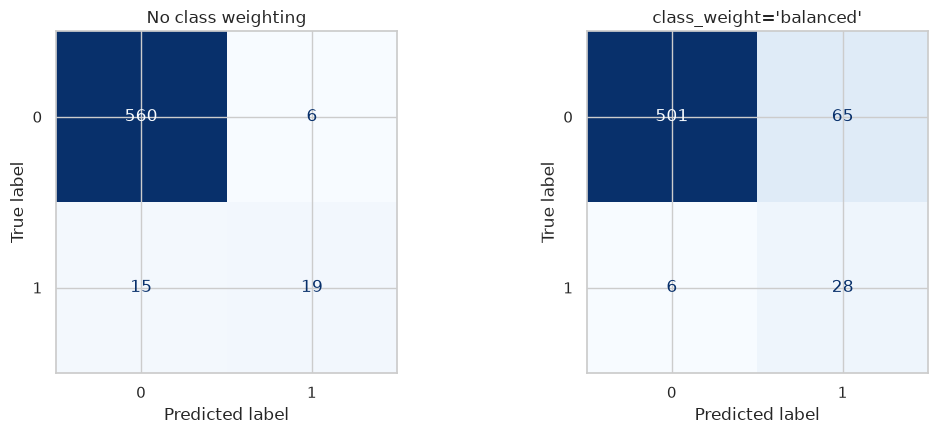

In [4]:
weighted = LogisticRegression(max_iter=5000, class_weight="balanced").fit(X_train, y_train)
weighted_pred = weighted.predict(X_test)

print(f"Logistic Regression (class_weight='balanced'):")
print(f"  accuracy={accuracy_score(y_test, weighted_pred):.3f}  precision={precision_score(y_test, weighted_pred):.3f}  "
      f"recall={recall_score(y_test, weighted_pred):.3f}  f1={f1_score(y_test, weighted_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("No class weighting")
ConfusionMatrixDisplay.from_predictions(y_test, weighted_pred, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("class_weight='balanced'")
plt.tight_layout()
plt.show()

Notice recall on the minority class typically jumps once weighting is
applied — at some cost to precision (more false positives). That tradeoff
is the point: class weighting shifts the decision boundary to care about
the minority class, it doesn't create free accuracy.

## 3. SMOTE (Synthetic Minority Oversampling Technique)

**Theory.** Instead of duplicating minority-class rows (which can cause
overfitting to those exact points) or discarding majority-class rows
(losing information), SMOTE generates **synthetic** minority-class points by
interpolating between existing minority samples and their nearest
minority-class neighbors.

**Important:** SMOTE must only be applied to the **training** data, after
the train/test split — applying it before splitting would leak synthetic
copies of test points into training.

In [5]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", np.bincount(y_train))
X_train_sm, y_train_sm = SMOTE(random_state=6).fit_resample(X_train, y_train)
print("After SMOTE: ", np.bincount(y_train_sm))

smote_model = LogisticRegression(max_iter=5000).fit(X_train_sm, y_train_sm)
smote_pred = smote_model.predict(X_test)
print(f"\nLogistic Regression (trained on SMOTE-balanced data):")
print(f"  accuracy={accuracy_score(y_test, smote_pred):.3f}  precision={precision_score(y_test, smote_pred):.3f}  "
      f"recall={recall_score(y_test, smote_pred):.3f}  f1={f1_score(y_test, smote_pred):.3f}")

Before SMOTE: [1322   78]
After SMOTE:  [1322 1322]

Logistic Regression (trained on SMOTE-balanced data):
  accuracy=0.888  precision=0.315  recall=0.824  f1=0.455


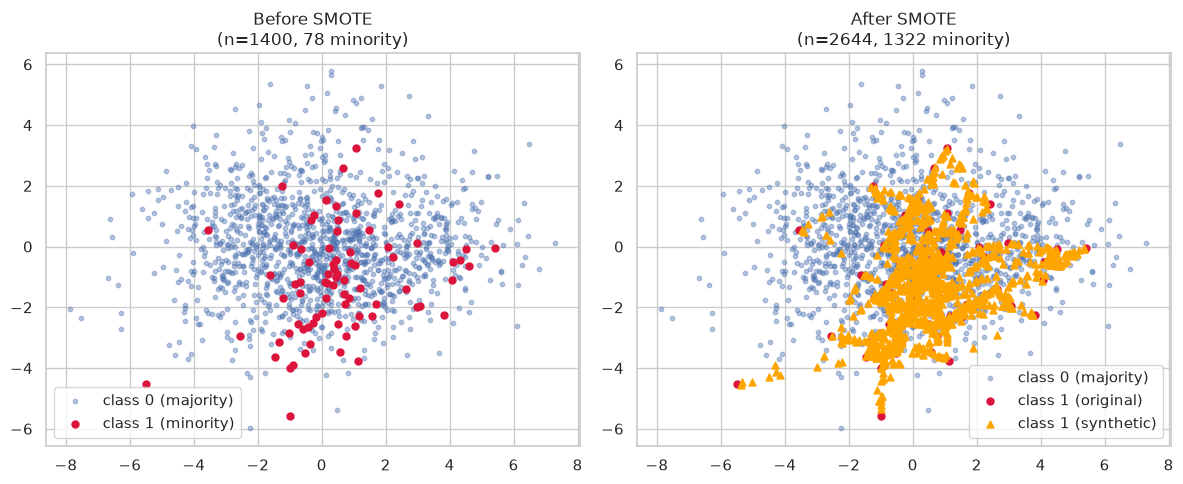

In [6]:
# Visualize: project to 2D via PCA to see the synthetic points relative to the originals
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=6).fit(X_train)
X_train_2d = pca.transform(X_train)
X_train_sm_2d = pca.transform(X_train_sm)

n_minority_original = np.bincount(y_train)[1]  # SMOTE appends synthetic rows after the original ones
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], s=10, alpha=0.4, label="class 0 (majority)")
axes[0].scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], s=25, color="crimson", label="class 1 (minority)")
axes[0].set_title(f"Before SMOTE\n(n={len(y_train)}, {np.bincount(y_train)[1]} minority)")
axes[0].legend()

minority_2d = X_train_sm_2d[y_train_sm == 1]
axes[1].scatter(X_train_sm_2d[y_train_sm == 0, 0], X_train_sm_2d[y_train_sm == 0, 1], s=10, alpha=0.4, label="class 0 (majority)")
axes[1].scatter(minority_2d[:n_minority_original, 0], minority_2d[:n_minority_original, 1],
                s=25, color="crimson", label="class 1 (original)")
axes[1].scatter(minority_2d[n_minority_original:, 0], minority_2d[n_minority_original:, 1],
                s=25, color="orange", marker="^", label="class 1 (synthetic)")
axes[1].set_title(f"After SMOTE\n(n={len(y_train_sm)}, {np.bincount(y_train_sm)[1]} minority)")
axes[1].legend()
plt.tight_layout()
plt.show()

The synthetic points (orange triangles) sit *between* real minority points —
exactly what interpolation should produce — filling in the minority region
rather than just duplicating the same handful of points.

## 4. Feature Importance & Permutation Importance

Tree ensembles expose `.feature_importances_` (mean impurity decrease, seen
in earlier modules), but that measure is biased toward high-cardinality
features and can be misleading. **Permutation importance** is more robust:
shuffle one feature's values (breaking its relationship with the target),
measure how much the model's score drops, and repeat per feature — a bigger
drop means that feature mattered more.

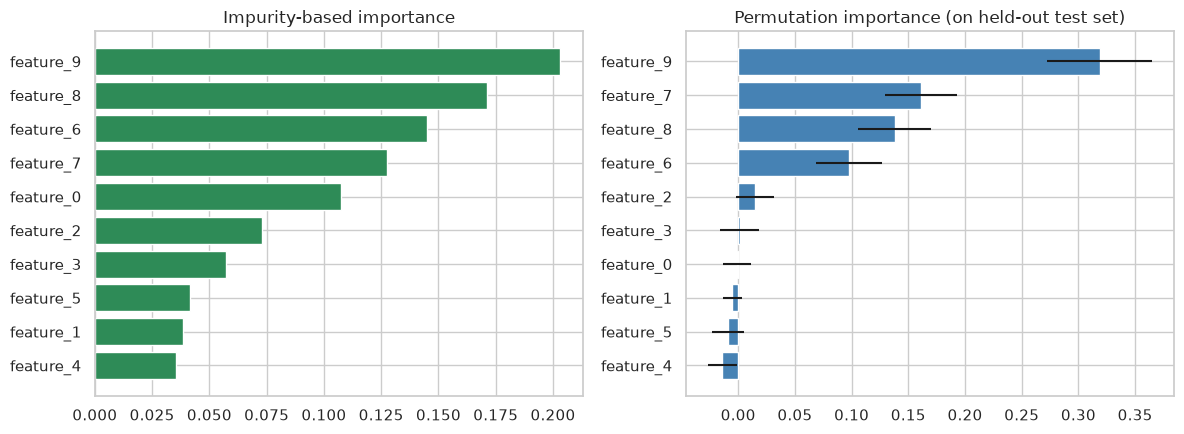

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(n_estimators=300, random_state=6).fit(X_train, y_train)
perm_result = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=6, scoring="f1")

feature_names = [f"feature_{i}" for i in range(X_imb.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

impurity_order = np.argsort(rf.feature_importances_)[::-1]
axes[0].barh(np.array(feature_names)[impurity_order], rf.feature_importances_[impurity_order], color="seagreen")
axes[0].invert_yaxis()
axes[0].set_title("Impurity-based importance")

perm_order = np.argsort(perm_result.importances_mean)[::-1]
axes[1].barh(np.array(feature_names)[perm_order], perm_result.importances_mean[perm_order],
             xerr=perm_result.importances_std[perm_order], color="steelblue")
axes[1].invert_yaxis()
axes[1].set_title("Permutation importance (on held-out test set)")

plt.tight_layout()
plt.show()

The two rankings usually agree on the top few features but can diverge —
permutation importance is computed on held-out data and reflects actual
generalization impact, while impurity-based importance is computed purely
from training-time splits.

## 5. Recursive Feature Elimination (RFE)

**Theory.** Starts with all features, repeatedly fits the model, drops the
least important feature (by the model's own importance/coefficient), and
repeats until the target number of features remains. Directly optimizes for
"which subset works best with *this* model" rather than a generic statistical
criterion.

In [8]:
from sklearn.feature_selection import RFE

rfe = RFE(estimator=LogisticRegression(max_iter=5000), n_features_to_select=5)
rfe.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    "feature": feature_names,
    "selected": rfe.support_,
    "rank": rfe.ranking_,
}).sort_values("rank")
display(ranking_df)

,feature,selected,rank
6,feature_6,True,1
7,feature_7,True,1
5,feature_5,True,1
8,feature_8,True,1
9,feature_9,True,1
4,feature_4,False,2
2,feature_2,False,3
3,feature_3,False,4
1,feature_1,False,5
0,feature_0,False,6


## 6. SelectKBest

**Theory.** A fast, model-agnostic approach: score each feature individually
against the target using a statistical test (e.g., ANOVA F-value for
classification via `f_classif`), then keep the top `k`. Doesn't account for
feature *interactions* the way RFE (wrapped around a real model) can, but is
much cheaper to compute.

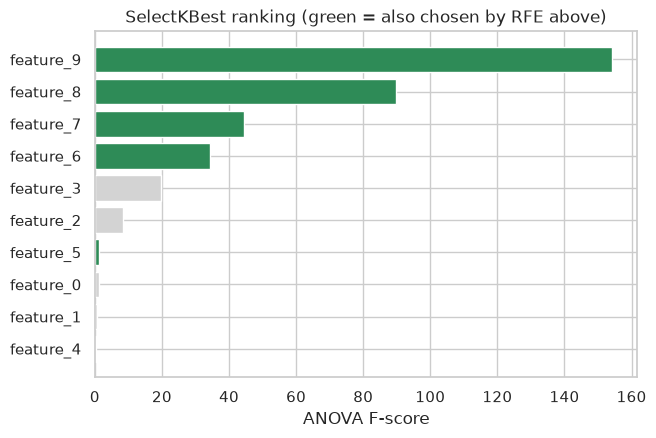

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_train, y_train)

scores_df = pd.DataFrame({"feature": feature_names, "f_score": selector.scores_}).sort_values("f_score", ascending=False)

plt.figure(figsize=(7, 4.5))
colors = ["seagreen" if f in ranking_df[ranking_df.selected]["feature"].values else "lightgray" for f in scores_df["feature"]]
plt.barh(scores_df["feature"], scores_df["f_score"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("ANOVA F-score")
plt.title("SelectKBest ranking (green = also chosen by RFE above)")
plt.show()

## Exercises

1. Change `weights=[0.95, 0.05]` to `[0.99, 0.01]` (more extreme imbalance) — how much worse does the "always predict class 0" baseline's recall get, and does SMOTE still recover useful recall?
2. Compare `RandomForestClassifier(class_weight="balanced")` against the plain version on the same imbalanced data — does the effect look similar to what we saw with Logistic Regression?
3. Change `RFE`'s `n_features_to_select` to 3 — do the same top features survive, or does the ranking shift?

## Key Takeaways

- On imbalanced data, accuracy can look great while the model is useless — always check precision/recall/F1 (or ROC-AUC) on the minority class.
- `class_weight="balanced"` is the cheapest first fix; SMOTE is a stronger (and more expensive) option when class weighting isn't enough — and must be applied only to training data, after the split.
- Permutation importance is a more trustworthy generalization check than impurity-based importance alone.
- RFE optimizes feature subsets for a specific model; SelectKBest is a fast, model-agnostic univariate filter — reach for RFE when interactions matter, SelectKBest for a quick first pass.